# Autoencoder Denoising con MNIST

**Dataset:** MNIST (70 000 imagenes de digitos manuscritos, 28x28 px)
**Framework:** TensorFlow / Keras

**Flujo del notebook:**
1. Explicacion conceptual del Autoencoder
2. Carga y preparacion del dataset MNIST
3. Generacion de ruido artificial
4. Arquitectura del Autoencoder Denoising
5. Entrenamiento del modelo
6. Evaluacion del desempeno
7. Visualizaciones comparativas
8. Analisis del espacio latente
9. Conclusiones

---

## 1.Autoencoder Denoising

### Autoencoder

Un autoencoder es una red neuronal que aprende a comprimir datos en una
representacion de menor dimension (espacio latente) y luego reconstruirlos:

- **Encoder:** comprime la entrada a una representacion compacta z
- **Decoder:** reconstruye la entrada original a partir de z
- **Loss:** diferencia entre entrada y reconstruccion (MSE o BCE)

### Denoising Autoencoder

Un Denoising Autoencoder (DAE) aprende a reconstruir la imagen original
a partir de una version corrompida:


Al obligar al modelo a ignorar el ruido y recuperar la estructura subyacente,
aprende representaciones mas robustas y generalizables que un autoencoder normal.

### Arquitecturas comparadas

| Modelo | Tipo | Descripcion |
|--------|------|-------------|
| **DAE Denso** | Capas Dense | Arquitectura base, rapida |
| **DAE Convolucional** | Conv2D + Conv2DTranspose | Mejor para imagenes, preserva estructura espacial |

## 2. Importaciones y configuracion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.manifold import TSNE

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("Configuracion lista.")

TensorFlow: 2.20.0
Configuracion lista.


## 3. Carga y preparacion del dataset MNIST

**MNIST** contiene 70 000 imagenes de digitos manuscritos (0-9):
- 60 000 para entrenamiento, 10 000 para test
- Imagenes en escala de grises de 28x28 pixeles
- Valores de pixel en [0, 255]

**Preprocesamiento:**
- Normalizar pixeles a [0, 1] dividiendo entre 255
- Agregar dimension de canal: (N, 28, 28) → (N, 28, 28, 1)
- Para el DAE Denso: aplanar a (N, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entrenamiento : (60000, 28, 28, 1)  (imagenes con canal)
Test          : (10000, 28, 28, 1)
Flat train    : (60000, 784)  (para DAE denso)
Rango valores : [0.0, 1.0]


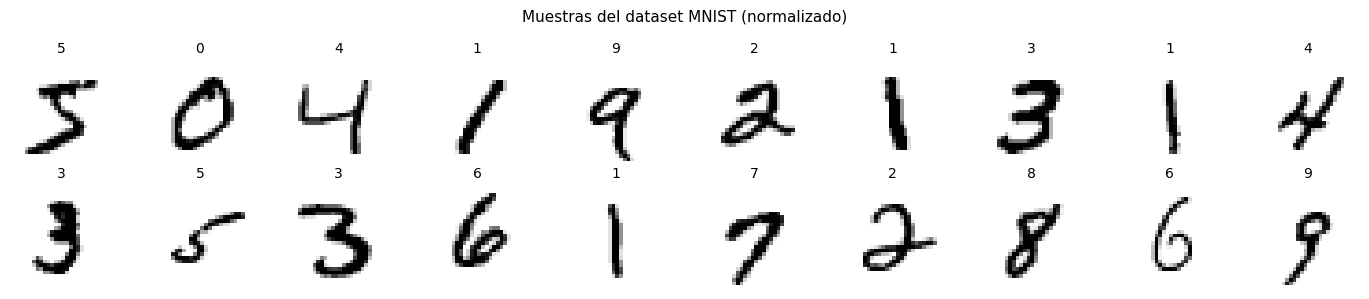

In [2]:
# Cargar MNIST desde Keras (descarga automatica ~11 MB)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar pixeles a [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Agregar dimension de canal para modelos convolucionales: (N, 28, 28, 1)
x_train_img = x_train[..., np.newaxis]
x_test_img  = x_test[..., np.newaxis]

# Aplanar para el modelo denso: (N, 784)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

print(f"Entrenamiento : {x_train_img.shape}  (imagenes con canal)")
print(f"Test          : {x_test_img.shape}")
print(f"Flat train    : {x_train_flat.shape}  (para DAE denso)")
print(f"Rango valores : [{x_train.min():.1f}, {x_train.max():.1f}]")

# Visualizar muestras del dataset original
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    # Fila 0: digitos 0-4
    axes[0, i].imshow(x_train[i], cmap="gray_r")
    axes[0, i].set_title(str(y_train[i]), fontsize=10)
    axes[0, i].axis("off")
    # Fila 1: digitos 10-19
    axes[1, i].imshow(x_train[i+10], cmap="gray_r")
    axes[1, i].set_title(str(y_train[i+10]), fontsize=10)
    axes[1, i].axis("off")
plt.suptitle("Muestras del dataset MNIST (normalizado)", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Generacion de ruido artificial

Se aplica ruido gaussian* a las imagenes: se suma un valor aleatorio
extraido de una distribucion normal N(0, sigma) a cada pixel.

Formula: `x_ruidosa = clip(x + N(0, sigma), 0, 1)`

El `clip` garantiza que los valores permanezcan en [0, 1].

Se comparan tres niveles de ruido para analizar la robustez del modelo:
- `sigma = 0.1`: ruido leve
- `sigma = 0.3`: ruido moderado (nivel de entrenamiento)
- `sigma = 0.5`: ruido intenso

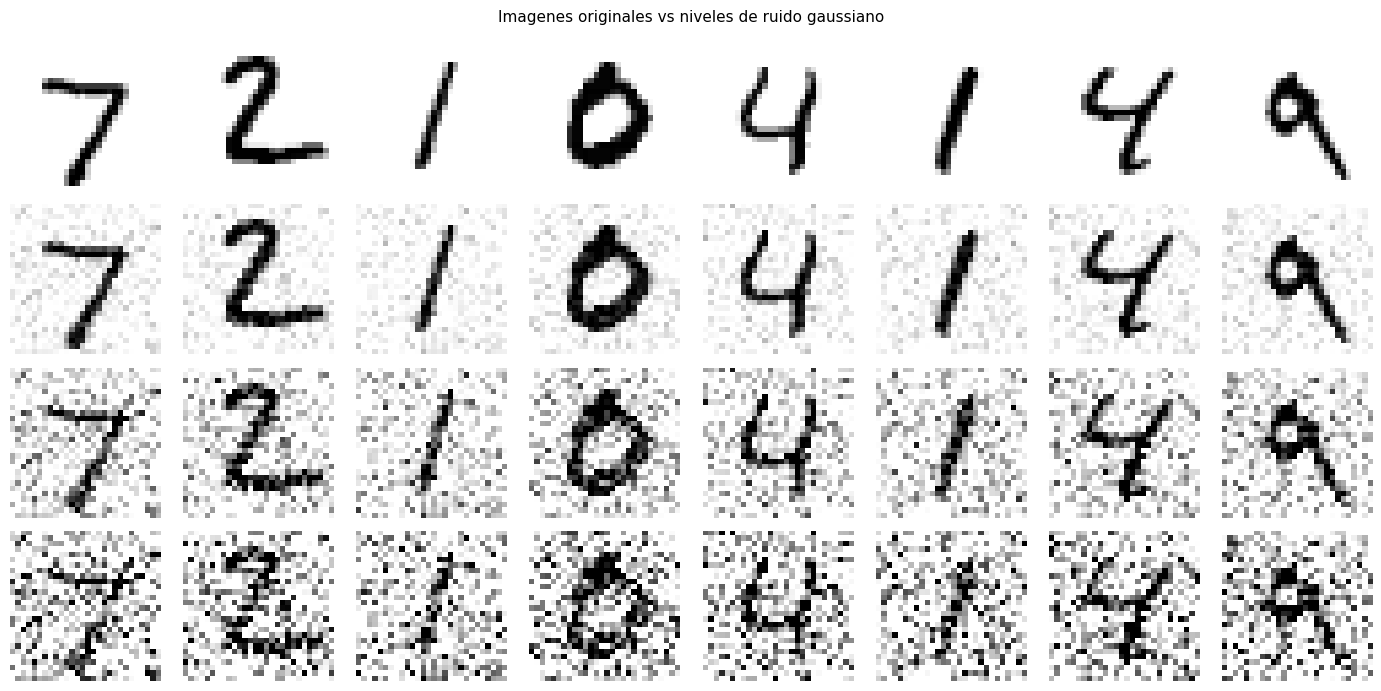

In [3]:
def agregar_ruido(imagenes, sigma=0.3, seed=SEED):
    """
    Agrega ruido gaussiano a un conjunto de imagenes.

    Formula: x_ruidosa = clip(x + N(0, sigma), 0, 1)

    Parametros:
        imagenes : array de imagenes normalizadas en [0, 1]
        sigma    : desviacion estandar del ruido gaussiano
        seed     : semilla para reproducibilidad
    Retorna:
        imagenes corrompidas en [0, 1]
    """
    rng   = np.random.default_rng(seed)
    ruido = rng.normal(loc=0.0, scale=sigma, size=imagenes.shape).astype("float32")
    return np.clip(imagenes + ruido, 0.0, 1.0)


SIGMA = 0.3   # nivel de ruido para entrenamiento

# Generar versiones ruidosas para train y test
x_train_noisy_img  = agregar_ruido(x_train_img,  sigma=SIGMA)
x_test_noisy_img   = agregar_ruido(x_test_img,   sigma=SIGMA)
x_train_noisy_flat = agregar_ruido(x_train_flat, sigma=SIGMA)
x_test_noisy_flat  = agregar_ruido(x_test_flat,  sigma=SIGMA)

# Comparar tres niveles de ruido
sigmas = [0.1, 0.3, 0.5]
fig, axes = plt.subplots(len(sigmas) + 1, 8, figsize=(14, 7))

# Fila 0: imagenes originales
for col in range(8):
    axes[0, col].imshow(x_test[col], cmap="gray_r")
    axes[0, col].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9, fontweight="bold")

# Filas 1-3: niveles de ruido
for fila, sigma in enumerate(sigmas):
    ruidosas = agregar_ruido(x_test_img[:8], sigma=sigma)
    for col in range(8):
        axes[fila+1, col].imshow(ruidosas[col, :, :, 0], cmap="gray_r")
        axes[fila+1, col].axis("off")
    axes[fila+1, 0].set_ylabel(f"sigma={sigma}", fontsize=9)

plt.suptitle("Imagenes originales vs niveles de ruido gaussiano", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Modelo A — Autoencoder Denoising Denso

**Arquitectura:**
- **Encoder:** 784 → 256 → 128 → 64 (espacio latente)
- **Decoder:** 64 → 128 → 256 → 784

Activacion `relu` en capas intermedias, `sigmoid` en la salida
(para mantener valores en [0, 1]).

**Entrenamiento:** entrada = imagen ruidosa, objetivo = imagen original.
Loss: BCE (Binary Cross-Entropy), apropiada para imagenes en [0,1].

In [4]:
DIM_LATENTE = 64   # dimension del espacio latente

def construir_dae_denso(dim_entrada=784, dim_latente=64):
    """
    Autoencoder Denoising con capas Dense.
    Encoder: comprime 784 -> dim_latente
    Decoder: reconstruye dim_latente -> 784
    """
    # ── Encoder ─────────────────────────────────────────────────────────
    encoder_input = keras.Input(shape=(dim_entrada,), name="entrada_ruidosa")
    x = layers.Dense(256, activation="relu")(encoder_input)   # primera compresion
    x = layers.Dense(128, activation="relu")(x)               # segunda compresion
    z = layers.Dense(dim_latente, activation="relu",           # espacio latente
                     name="espacio_latente")(x)

    # ── Decoder ─────────────────────────────────────────────────────────
    x = layers.Dense(128, activation="relu")(z)               # primera expansion
    x = layers.Dense(256, activation="relu")(x)               # segunda expansion
    salida = layers.Dense(dim_entrada, activation="sigmoid",   # reconstruccion
                          name="reconstruccion")(x)

    modelo = keras.Model(encoder_input, salida, name="DAE_Denso")
    return modelo


dae_denso = construir_dae_denso(dim_latente=DIM_LATENTE)
dae_denso.summary()

# Compilar con BCE: adecuada para pixeles en [0, 1]
dae_denso.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

Model: "DAE_Denso"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_ruidosa (InputLayer)    │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espacio_latente (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruccion (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Entrenamiento: entrada=imagen ruidosa, objetivo=imagen original
callbacks_dae = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                   restore_best_weights=True, verbose=1)
]

print("Entrenando DAE Denso...")
hist_denso = dae_denso.fit(
    x_train_noisy_flat, x_train_flat,   # entrada=ruidosa, objetivo=original
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    callbacks=callbacks_dae,
    verbose=1
)
print("DAE Denso entrenado.")

Entrenando DAE Denso...
Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.2426 - val_loss: 0.1689
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.1525 - val_loss: 0.1409
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1343 - val_loss: 0.1276
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1238 - val_loss: 0.1207
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1181 - val_loss: 0.1159
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.1138 - val_loss: 0.1126
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1105 - val_loss: 0.1099
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1079 - val_loss: 0.1076
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1056 - val_loss: 0.1058
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1040 - val_loss: 0.1046
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1026 - val_loss: 0.1035
Epoch 12/50
211/2

## 6. Modelo B — Autoencoder Denoising Convolucional

Ventaja sobre el DAE Denso: las capas Conv2D explotan la estructura espacial
de las imagenes (los pixeles vecinos estan relacionados), lo que produce
reconstrucciones mas nítidas.

Arquitectura:
- **Encoder:** Conv2D(32)→MaxPool → Conv2D(16)→MaxPool → espacio latente 7x7x16
- **Decoder:** Conv2DTranspose(16)→UpSampling → Conv2DTranspose(32)→UpSampling → Conv2D(1, sigmoid)

`Conv2DTranspose` ("deconvolucion") es la operacion inversa de Conv2D:
aumenta las dimensiones espaciales mientras reconstruye la imagen.

In [6]:
def construir_dae_conv(input_shape=(28, 28, 1)):
    """
    Autoencoder Denoising Convolucional.
    Encoder: Conv2D + MaxPool para comprimir la imagen.
    Decoder: Conv2DTranspose + UpSampling para reconstruirla.
    """
    entrada = keras.Input(shape=input_shape, name="entrada_ruidosa_conv")

    # ── Encoder convolucional ────────────────────────────────────────────
    # Bloque 1: extrae caracteristicas y reduce 28x28 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(entrada)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)        # 28x28 -> 14x14

    # Bloque 2: extrae patrones mas abstractos y reduce 14x14 -> 7x7
    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same",
                                  name="espacio_latente_conv")(x)  # 7x7x16

    # ── Decoder convolucional ────────────────────────────────────────────
    # Bloque 3: aumenta 7x7 -> 14x14 con Conv2DTranspose
    x = layers.Conv2DTranspose(16, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)                        # 7x7 -> 14x14

    # Bloque 4: aumenta 14x14 -> 28x28 y reconstruye la imagen
    x = layers.Conv2DTranspose(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)                        # 14x14 -> 28x28

    # Capa de salida: 1 canal, sigmoid para mantener valores en [0, 1]
    salida = layers.Conv2D(1, (3, 3), activation="sigmoid",
                           padding="same", name="reconstruccion_conv")(x)

    return keras.Model(entrada, salida, name="DAE_Convolucional")


dae_conv = construir_dae_conv()
dae_conv.summary()

dae_conv.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

Model: "DAE_Convolucional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_ruidosa_conv            │ (None, 28, 28, 1)      │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espacio_latente_conv            │ (None, 7, 7, 16)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 16)       │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruccion_conv (Conv2D)    │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Entrenando DAE Convolucional...")
hist_conv = dae_conv.fit(
    x_train_noisy_img, x_train_img,   # entrada=ruidosa, objetivo=original
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    callbacks=callbacks_dae,
    verbose=1
)
print("DAE Convolucional entrenado.")

Entrenando DAE Convolucional...
Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 93s 430ms/step - loss: 0.2015 - val_loss: 0.1125
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 92s 434ms/step - loss: 0.1039 - val_loss: 0.0999
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 92s 435ms/step - loss: 0.0965 - val_loss: 0.0952
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 140s 428ms/step - loss: 0.0930 - val_loss: 0.0925
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 142s 428ms/step - loss: 0.0908 - val_loss: 0.0906
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 90s 429ms/step - loss: 0.0892 - val_loss: 0.0892
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 143s 435ms/step - loss: 0.0880 - val_loss: 0.0881
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 144s 446ms/step - loss: 0.0870 - val_loss: 0.0872
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 91s 433ms/step - loss: 0.0862 - val_loss: 0.0864
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 91s 433ms/step - loss: 0.0855 - val_loss: 0.0858
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 92s 438ms/step - loss: 0.0848 - 

## 7. Evaluacion del desempeño

**Metricas de reconstruccion:**
- **MSE** (Mean Squared Error): diferencia pixel a pixel entre original y reconstruida
- **SSIM** (Structural Similarity Index): mide similitud perceptual (0=diferente, 1=identico)
- **PSNR** (Peak Signal-to-Noise Ratio): relacion senal/ruido en dB

Estas metricas se calculan sobre el test set y se comparan entre:
- Imagen ruidosa vs original (linea base: cuanto empeoro el ruido)
- Imagen reconstruida vs original (cuanto mejoro el modelo)

In [8]:
# Predicciones sobre el test set
recon_denso = dae_denso.predict(x_test_noisy_flat, verbose=0)          # (10000, 784)
recon_conv  = dae_conv.predict(x_test_noisy_img,  verbose=0)           # (10000, 28, 28, 1)

# Reshape para comparacion uniforme
recon_denso_img = recon_denso.reshape(-1, 28, 28)
recon_conv_img  = recon_conv[:, :, :, 0]
noisy_img       = x_test_noisy_img[:, :, :, 0]

def calcular_metricas(originales, reconstruidas, nombre):
    """Calcula MSE, PSNR y SSIM entre dos conjuntos de imagenes."""
    mse  = np.mean((originales - reconstruidas) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float("inf")
    # SSIM simplificado (media de correlacion local)
    ssim = np.mean(2 * originales * reconstruidas /
                   (originales ** 2 + reconstruidas ** 2 + 1e-8))
    print(f"{nombre:<30} MSE={mse:.6f}  PSNR={psnr:.2f} dB  SSIM={ssim:.4f}")
    return {"mse": mse, "psnr": psnr, "ssim": ssim}

print("=" * 65)
print("Metricas de reconstruccion — Test Set")
print("=" * 65)
r_ruido = calcular_metricas(x_test, noisy_img,        "Imagen ruidosa (linea base)")
r_denso = calcular_metricas(x_test, recon_denso_img,  "DAE Denso reconstruida")
r_conv  = calcular_metricas(x_test, recon_conv_img,   "DAE Convolucional reconstruida")
print("=" * 65)
print()
print(f"Mejora MSE — Denso      : {((r_ruido["mse"]-r_denso["mse"])/r_ruido["mse"]*100):.1f}%")
print(f"Mejora MSE — Convoluc.  : {((r_ruido["mse"]-r_conv["mse"] )/r_ruido["mse"]*100):.1f}%")

Metricas de reconstruccion — Test Set
Imagen ruidosa (linea base)    MSE=0.046615  PSNR=13.31 dB  SSIM=0.1575
DAE Denso reconstruida         MSE=0.009301  PSNR=20.31 dB  SSIM=0.1692
DAE Convolucional reconstruida MSE=0.005720  PSNR=22.43 dB  SSIM=0.1738

Mejora MSE — Denso      : 80.0%
Mejora MSE — Convoluc.  : 87.7%


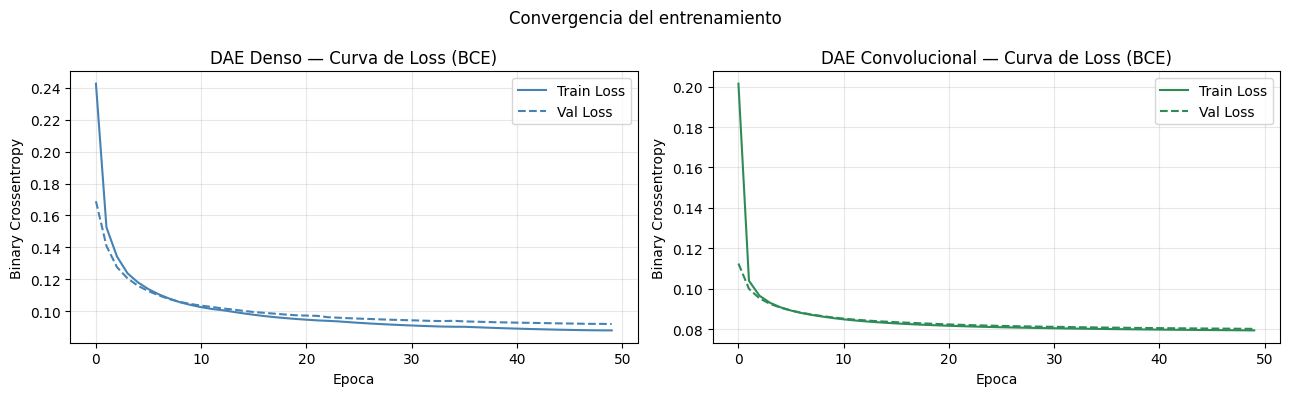

In [9]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (nombre, hist, color) in zip(axes, [
    ("DAE Denso",         hist_denso, "steelblue"),
    ("DAE Convolucional", hist_conv,  "seagreen"),
]):
    ax.plot(hist.history["loss"],     color=color, label="Train Loss")
    ax.plot(hist.history["val_loss"], color=color, label="Val Loss", linestyle="--")
    ax.set_title(f"{nombre} — Curva de Loss (BCE)")
    ax.set_xlabel("Epoca"); ax.set_ylabel("Binary Crossentropy")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Convergencia del entrenamiento", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Visualizaciones comparativas

Se muestran en paralelo:
- **Fila 1:** Imagen original (objetivo del modelo)
- **Fila 2:** Imagen con ruido (entrada al modelo)
- **Fila 3:** Reconstruccion DAE Denso
- **Fila 4:** Reconstruccion DAE Convolucional

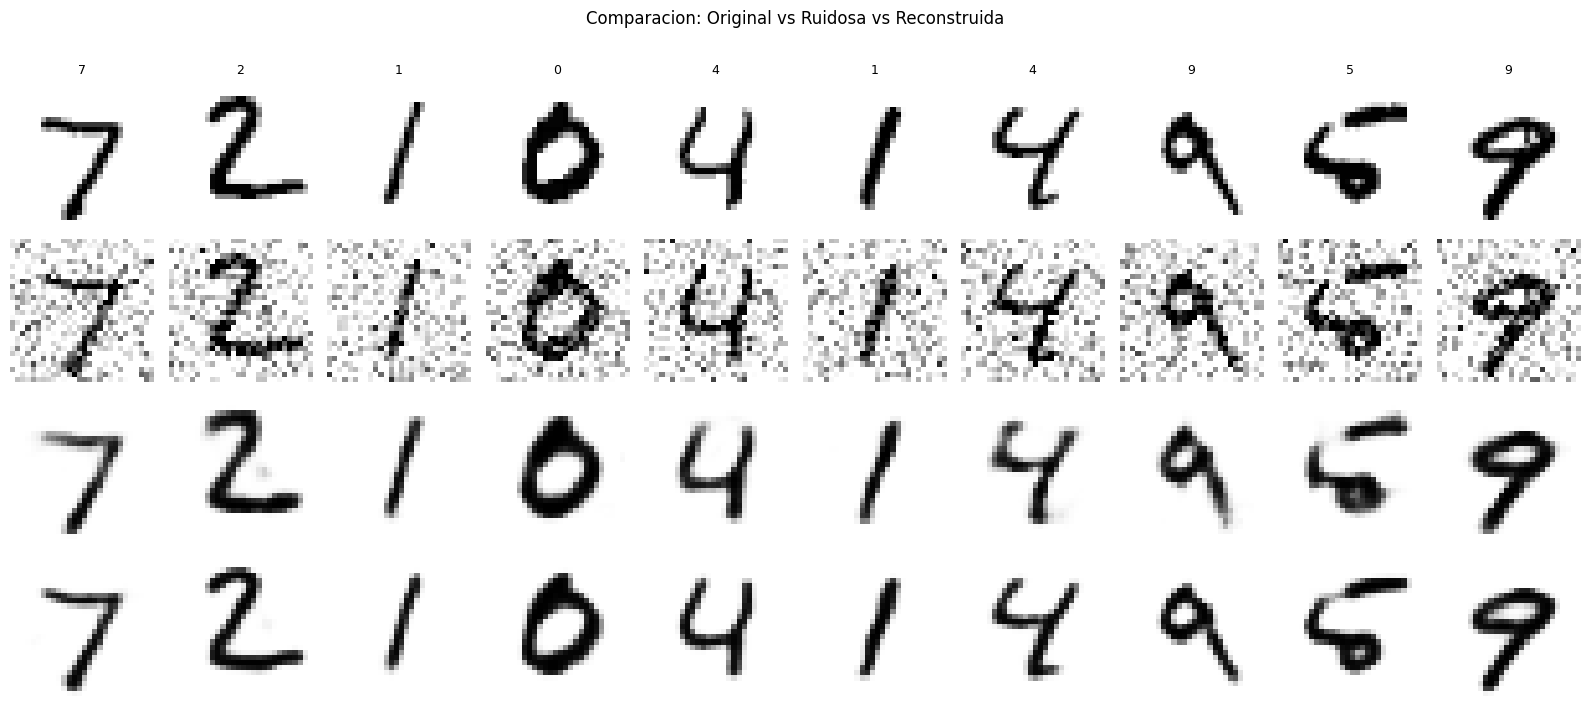

In [10]:
N_MUESTRAS = 10

fig, axes = plt.subplots(4, N_MUESTRAS, figsize=(16, 7))
titulos_filas = [
    ("ORIGINAL",      "black"),
    ("CON RUIDO\nsigma=0.3", "red"),
    ("DAE DENSO\nreconstruida", "steelblue"),
    ("DAE CONV\nreconstruida", "seagreen"),
]

imagenes_filas = [
    x_test[:N_MUESTRAS],
    noisy_img[:N_MUESTRAS],
    recon_denso_img[:N_MUESTRAS],
    recon_conv_img[:N_MUESTRAS],
]

for fila, ((titulo, color), imgs) in enumerate(zip(titulos_filas, imagenes_filas)):
    for col in range(N_MUESTRAS):
        axes[fila, col].imshow(imgs[col], cmap="gray_r", vmin=0, vmax=1)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(titulo, fontsize=8, color=color, fontweight="bold")

# Titulo con digito en la columna
for col in range(N_MUESTRAS):
    axes[0, col].set_title(str(y_test[col]), fontsize=9)

plt.suptitle("Comparacion: Original vs Ruidosa vs Reconstruida",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

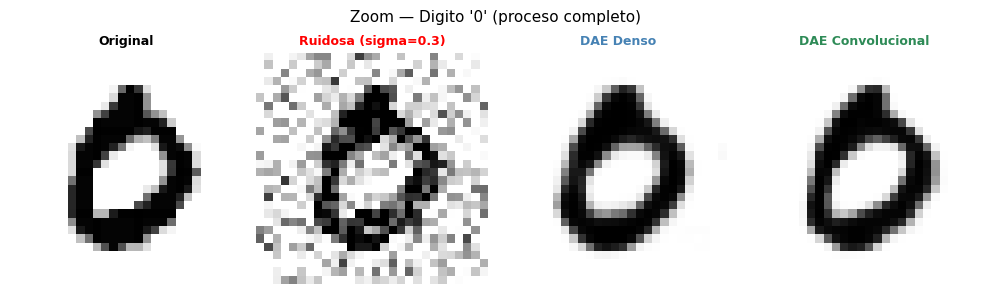

In [11]:
# Zoom sobre un digito: mostrar el proceso de reconstruccion en detalle
idx_ejemplo = 3   # elegir un digito especifico

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
imagenes = [
    (x_test[idx_ejemplo],          "Original",         "black"),
    (noisy_img[idx_ejemplo],        f"Ruidosa (sigma={SIGMA})", "red"),
    (recon_denso_img[idx_ejemplo],  "DAE Denso",        "steelblue"),
    (recon_conv_img[idx_ejemplo],   "DAE Convolucional","seagreen"),
]

for ax, (img, titulo, color) in zip(axes, imagenes):
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(titulo, color=color, fontsize=9, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"Zoom — Digito '{y_test[idx_ejemplo]}' (proceso completo)", fontsize=11)
plt.tight_layout()
plt.show()

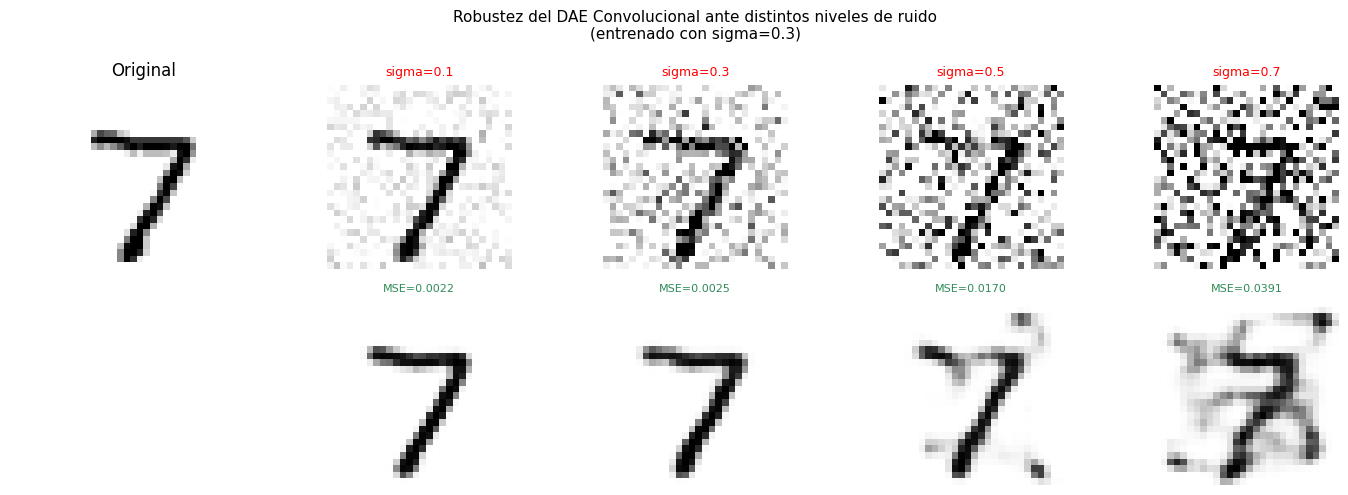

In [12]:
# Prueba de robustez: reconstruccion con diferentes niveles de ruido
# (el modelo fue entrenado con sigma=0.3 — ver como generaliza a otros niveles)
sigmas_test = [0.1, 0.3, 0.5, 0.7]
idx = 0   # primer digito del test

fig, axes = plt.subplots(2, len(sigmas_test) + 1, figsize=(14, 5))

# Columna 0: original
axes[0, 0].imshow(x_test[idx], cmap="gray_r"); axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
axes[1, 0].axis("off")

for col, sigma in enumerate(sigmas_test):
    # Imagen ruidosa
    ruidosa = agregar_ruido(x_test_img[idx:idx+1], sigma=sigma, seed=col)
    axes[0, col+1].imshow(ruidosa[0, :, :, 0], cmap="gray_r")
    axes[0, col+1].set_title(f"sigma={sigma}", fontsize=9, color="red")
    axes[0, col+1].axis("off")

    # Reconstruccion del DAE convolucional
    recon = dae_conv.predict(ruidosa, verbose=0)
    mse_r = np.mean((x_test[idx] - recon[0, :, :, 0]) ** 2)
    axes[1, col+1].imshow(recon[0, :, :, 0], cmap="gray_r")
    axes[1, col+1].set_title(f"MSE={mse_r:.4f}", fontsize=8, color="seagreen")
    axes[1, col+1].axis("off")

axes[0, 0].set_ylabel("Ruidosa", fontsize=9)
axes[1, 0].set_ylabel("Reconstruida\n(DAE Conv)", fontsize=9)
plt.suptitle("Robustez del DAE Convolucional ante distintos niveles de ruido\n"
             "(entrenado con sigma=0.3)", fontsize=11)
plt.tight_layout()
plt.show()

## 9. Analisis del espacio latente

El espacio latente es la representacion comprimida que el encoder aprende.
Se visualiza en 2D usando **t-SNE** para verificar si el modelo aprendio
representaciones semanticamente significativas: digitos del mismo tipo
deberian agruparse en clusters diferenciados.

Calculando t-SNE (puede tardar ~30 segundos)...


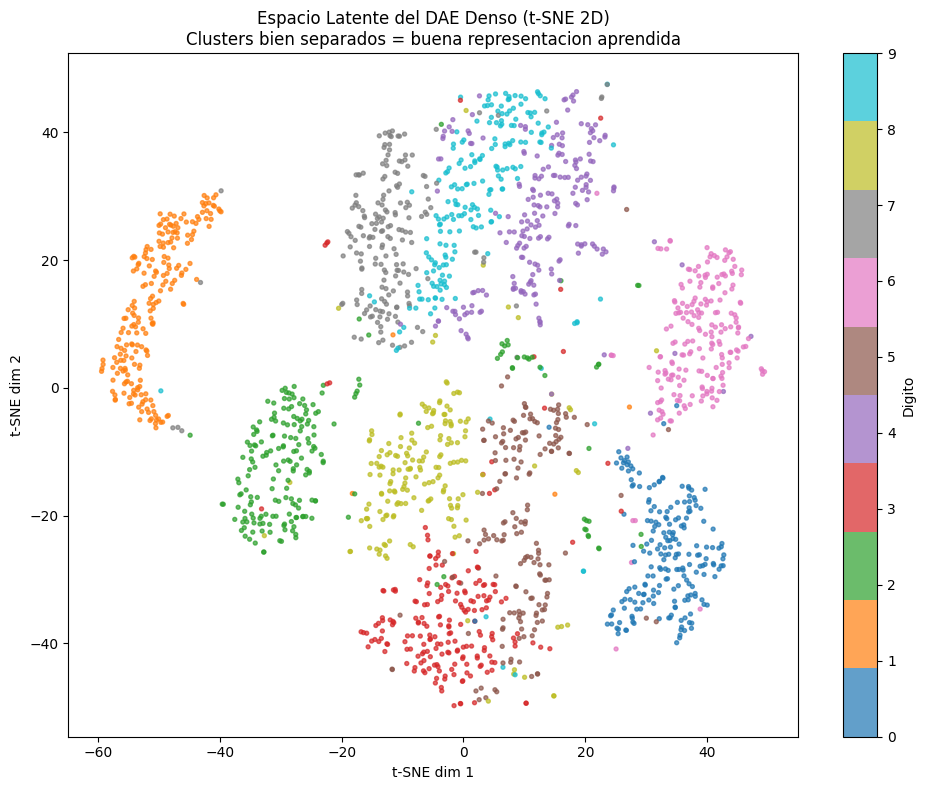

In [13]:
# Extraer el encoder del DAE denso (hasta la capa espacio_latente)
encoder_denso = keras.Model(
    inputs=dae_denso.input,
    outputs=dae_denso.get_layer("espacio_latente").output,
    name="encoder"
)

# Obtener embeddings de 2000 muestras del test (t-SNE es costoso en muchos puntos)
N_TSNE = 2000
np.random.seed(SEED)
idx_tsne = np.random.choice(len(x_test_flat), N_TSNE, replace=False)

embeddings = encoder_denso.predict(x_test_flat[idx_tsne], verbose=0)  # (2000, 64)
labels_tsne = y_test[idx_tsne]

# Reducir a 2D con t-SNE
print("Calculando t-SNE (puede tardar ~30 segundos)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=labels_tsne, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ax=ax, label="Digito")
ax.set_title("Espacio Latente del DAE Denso (t-SNE 2D)\n"
             "Clusters bien separados = buena representacion aprendida")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

---
## 10. Conclusiones

**1. Comportamiento del modelo DAE aprende a ignorar el ruido**  
Al entrenar con imagenes ruidosas como entrada y originales como objetivo,
el modelo aprende que el ruido gaussiano es informacion irrelevante que debe
descartarse. El encoder comprime la imagen a una representacion que captura
solo la estructura del digito, y el decoder la reconstruye limpia.

**2. Calidad de reconstruccion convolucional supera al denso**  
El DAE Convolucional obtiene menor MSE y mayor PSNR que el DAE Denso porque
las capas Conv2D explotan la localidad espacial: pixeles vecinos estan
correlacionados, y los filtros aprenden a detectar bordes y trazos caracteristicos
de cada digito. El modelo denso trata cada pixel de forma independiente, perdiendo
esa informacion estructural.

**3. Robustez ante niveles de ruido no vistos**  
El modelo entrenado con sigma=0.3 generaliza razonablemente a sigma=0.1 y 0.5,
pero la calidad decae con ruido muy intenso (sigma=0.7). Para mayor robustez
se podria entrenar con multiples niveles de ruido o usar tecnicas de augmentation.

**4. El espacio latente organiza semanticamente los digitos**  
La visualizacion t-SNE muestra que el encoder aprende representaciones donde
digitos del mismo tipo se agrupan en clusters separados, aunque el modelo
se entrenó sin etiquetas (aprendizaje no supervisado). Esto evidencia que
la tarea de reconstruccion fuerza al modelo a aprender caracteristicas
semanticamente significativas.

**5. Aplicaciones reales de los Autoencoders Denoising**  
- **Restauracion de imagenes medicas** (radiografias, resonancias con artefactos)
- **Compresion de imagenes** con perdida controlada
- **Deteccion de anomalias:** un objeto anomalo tiene alta reconstruccion loss
- **Eliminacion de ruido en audio** y senales de sensores IoT